# MS Elevate AICTE Internship Capstone Project

#### Name: Sushil Kumar Gauda
#### Batch : MS Elevate Azure January Batch 2026
#### AICTE Student ID: STU68f8ea469546c1761143366
#### Email : sushil.23iot@cambridge.edu.in


# Title : SolarPredict - Solar Power Output Prediction System

## Introduction

Solar energy plays an important role in sustainable development.
Accurate prediction of solar power output helps in:

- Energy planning
- Performance monitoring
- Maintenance scheduling
- Improving renewable energy efficiency

This project uses Linear Regression to predict solar power output
based on environmental factors such as irradiation and temperature.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

## Dataset Description

Dataset Used:
Solar Power Generation Data (Plant 1) – Kaggle

Features used:
- IRRADIATION
- AMBIENT_TEMPERATURE
- MODULE_TEMPERATURE
- AC_POWER (Target Variable)

AC_POWER is converted from Watts to kilowatts (kW) for better interpretation.


In [ ]:
generation = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

data = pd.merge(generation, weather, on='DATE_TIME')

model_data = data[['IRRADIATION',
                   'AMBIENT_TEMPERATURE',
                   'MODULE_TEMPERATURE',
                   'AC_POWER']].dropna()

model_data['AC_POWER_kW'] = model_data['AC_POWER'] / 1000
model_data.head()

/tmp/ipython-input-603982631.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,AC_POWER,AC_POWER_kW
0,0.0,25.184316,22.857507,0.0,0.0
1,0.0,25.184316,22.857507,0.0,0.0
2,0.0,25.184316,22.857507,0.0,0.0
3,0.0,25.184316,22.857507,0.0,0.0
4,0.0,25.184316,22.857507,0.0,0.0


## Correlation Analysis

This heatmap shows the relationship between environmental features
and solar power output.

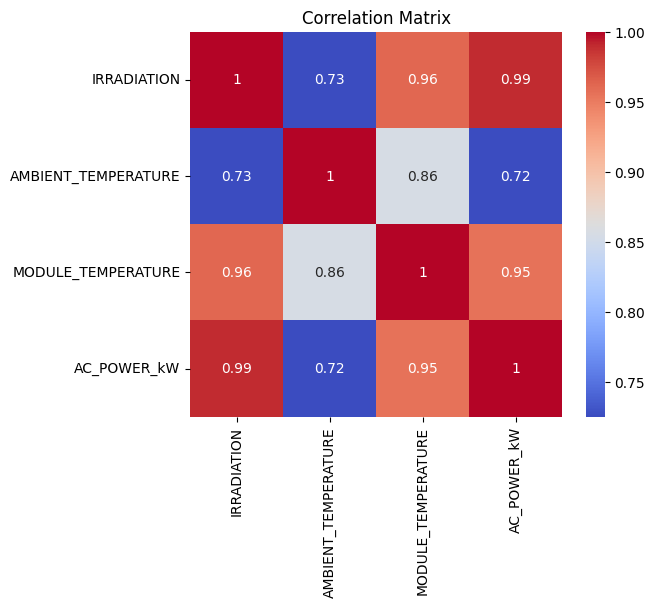

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(model_data[['IRRADIATION',
                        'AMBIENT_TEMPERATURE',
                        'MODULE_TEMPERATURE',
                        'AC_POWER_kW']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Model Training - Linear Regression

Linear Regression is used because solar power output
is strongly dependent on irradiation in a near-linear manner.

In [ ]:
X = model_data[['IRRADIATION',
                'AMBIENT_TEMPERATURE',
                'MODULE_TEMPERATURE']]

y = model_data['AC_POWER_kW']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.026309051276251966
RMSE: 0.05551243762482292
R2 Score: 0.9800288894346422


In [ ]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-Validation Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross-Validation Scores: [0.98731797 0.9835753  0.98294825 0.9626083  0.97419133]
Average CV R2: 0.9781282298890691


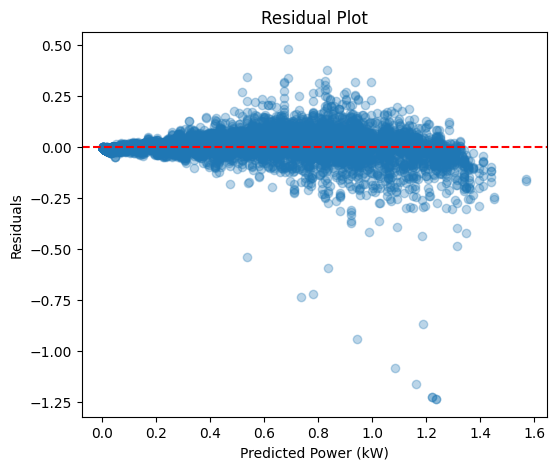

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Power (kW)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
def solar_recommendation(irradiation, ambient_temp, module_temp):

    input_df = pd.DataFrame({
        'IRRADIATION': [irradiation],
        'AMBIENT_TEMPERATURE': [ambient_temp],
        'MODULE_TEMPERATURE': [module_temp]
    })

    predicted_power = model.predict(input_df)[0]

    print(f"Predicted Solar Power Output: {predicted_power:.2f} kW")

    if irradiation > 800 and predicted_power < 0.5:
        print("Recommendation: Inspect solar panels for possible inefficiency.")

    elif module_temp > 50:
        print("Recommendation: High Temperature may reduce Efficiency.")

    elif irradiation < 200:
        print("Recommendation: Low Sunlight. Reduced Output Expected.")

    else:
        print("Recommendation: System Operating Normally.")


## Conclusion

The Linear Regression model achieved high accuracy (R² ≈ 0.98).

The system successfully predicts solar power output
and provides basic operational recommendations.

This project demonstrates how machine learning can assist
in renewable energy planning and sustainability.
